In [119]:
# imports
import numpy as np
import math
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [120]:
# constants

Q = 100 # dispersion constant
u = 1 # wind speed
H = 0 # height 

ay, by = 0.5, 0.92
az, bz = 0.5, 0.87

In [121]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_resnet_source_estimator():
    input_layer = layers.Input(shape=(3, 4))  # 3 drones, each with [x, y, z, c]

    x = layers.Flatten()(input_layer)
    x = layers.Dense(128, activation='relu')(x)

    # Residual block 1
    x_skip = x
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(128, activation=None)(x)
    x = layers.Add()([x, x_skip])
    x = layers.Activation('relu')(x)

    # Residual block 2
    x_skip = x
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(128, activation=None)(x)
    x = layers.Add()([x, x_skip])
    x = layers.Activation('relu')(x)

    # Output: predicted source location
    output = layers.Dense(3, activation=None)(x)

    return Model(inputs=input_layer, outputs=output)


In [122]:
def plume_function_loss(x0, y0, z0, x, y, z, Q=100.0, u=1.0, ay=1.0, by=0.92, az=1.0, bz=0.87):
    dx = tf.maximum(tf.abs(x - x0), 0.0001)
    dy = y - y0
    dz = z - z0

    # sigma_y = tf.maximum(ay * tf.pow(dx, by), 0.0002)
    # sigma_z = tf.maximum(az * tf.pow(dx, bz), 0.0002)
    sigma_y = 10
    sigma_z = 12

    part1 = Q / (2.0 * math.pi * u * sigma_y * sigma_z)
    part2 = tf.exp(-0.5 * tf.square(dy / sigma_y))
    part3 = tf.exp(-0.5 * tf.square(dz / sigma_z))

    return part1 * part2 * part3


def conc_loss(y_true, y_pred):
    # Unpack true and predicted positions
    x0, y0, z0 = tf.unstack(y_true, axis=-1)
    x, y, z = tf.unstack(y_pred, axis=-1)

    # Concentration loss (how well predicted position reproduces known concentration)
    c_true = 200.0  # Or use tf.constant if you want
    c_pred = plume_function_loss(x0, y0, z0, x, y, z)
    conc_loss_val = tf.abs(c_true - c_pred)

    # Position loss (Euclidean distance)
    pos_loss_val = tf.norm(y_true - y_pred, axis=-1)

    # Combine both (equal weighting)
    total_loss = 0.5 * conc_loss_val + 0.5 * pos_loss_val
    return total_loss



In [130]:
# generating data

def plume_function(x0, y0, z0, x, y, z):
    dx = max(x - x0, 0.0001)/10
    dy = max(y - y0, 0.0001)/10
    dz = max(z - z0, 0.0001)/10

    s_y = ay * dx**by
    s_z = az * dx**bz
    s_y = max(s_y, 0.00002)
    s_z = max(s_z, 0.00002)

    term1 = Q / (2 * np.pi * s_y * s_z * u)
    term2 = np.exp(-dy**2 / (2 * s_y**2))
    term3 = np.exp(-(dz - H)**2 / (2 * s_z**2))
    c = term1 * term2 * term3
    # c = min(c, 300)
    return c


# def generate_3_points_on_sphere(source, radius):
#     source = np.array(source)
#     points = []

#     for _ in range(3):
#         # Random spherical coordinates
#         theta = np.random.uniform(0, 2 * np.pi)
#         phi = np.arccos(np.random.uniform(-1, 1))

#         # Spherical to Cartesian
#         x = radius * np.sin(phi) * np.cos(theta)
#         y = radius * np.sin(phi) * np.sin(theta)
#         z = radius * np.cos(phi)

#         # Shift by source position
#         point = source + np.array([x, y, z])
#         points.append(point)

#     return np.array(points)

import numpy as np

def generate_3_points_downwind(source, radius):
    source = np.array(source)
    points = []

    while len(points) < 3:
        # Random spherical coordinates
        theta = np.random.uniform(0, 2 * np.pi)
        phi = np.random.uniform(0, np.pi)

        # Spherical to Cartesian
        x = radius * np.sin(phi) * np.cos(theta)
        y = radius * np.sin(phi) * np.sin(theta)
        z = radius * np.cos(phi)

        point = source + np.array([x, y, z])

        # ✅ Only keep point if it is downwind (x > x0)
        if point[0] > source[0]:
            points.append(point)

    return np.array(points)


def generate_data(n_samples=10000):
    X, Y = [], []

    for _ in range(n_samples):
        x0, y0, z0 = np.random.uniform(0, 5, 3)
        source = [x0, y0, z0]

        radi = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 2, 3]

        for r in radi:
            concentrations_drone = []
            drone_points = generate_3_points_downwind(source, r).tolist()

            for drone in drone_points:
                x, y, z = drone
                c = plume_function(x0, y0, z0, x, y, z)
                concentrations_drone.append(c)
            
            for index in range(3):
                drone_points[index].append(concentrations_drone[index])
            X.append(drone_points)
            Y.append([x0, y0, z0])
        
    return np.array(X), np.array(Y)

In [131]:
X_train, Y_train = generate_data()
X_val, Y_val = generate_data()


In [125]:
print(len(X_train))
print(len(X_train[0]))
print(len(X_train[0][0]))

80000
3
4


In [132]:
# Give in source number
def point_spread(allPoints):
    x_points = []
    y_points = []
    z_points = []
    concentrations = []

    for points in allPoints:       # points shape: (3, 4) per timestep probably
        for drone in points:
            x_points.append(drone[0])
            y_points.append(drone[1])
            z_points.append(drone[2])
            concentrations.append(drone[3])

    # print("Actual Source: ", dataset_y[point])
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.hist(x_points, bins=50, color='red', edgecolor='black')
    plt.xlabel('X')
    plt.ylabel('Frequency')
    plt.title('X Distribution')
    plt.grid(True)

    plt.subplot(1, 4, 2)
    plt.hist(y_points, bins=50, color='green', edgecolor='black')
    plt.xlabel('Y')
    plt.title('Y Distribution')
    plt.grid(True)

    plt.subplot(1, 4, 3)
    plt.hist(z_points, bins=50, color='blue', edgecolor='black')
    plt.xlabel('Z')
    plt.title('Z Distribution')
    plt.grid(True)

    plt.subplot(1, 4, 4)
    plt.hist(concentrations, bins=50, range=(0, 3000), color='skyblue', edgecolor='black')
    plt.xlabel('Concentration')
    plt.title('Concentration Distribution')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # # Grid
    # x_range = np.linspace(0, 10, 10)    # downwind
    # y_range = np.linspace(0, 10, 10)    # lateral
    # z_plane = height_slice                           # fixed height cross-section

    # # Evaluate on cross-section at z
    # X, Y = np.meshgrid(x_range, y_range, indexing='ij')
    # Z = np.full_like(X, z_plane)
    # C = np.zeros_like(X)
    # for i in range(X.shape[0]):
    #     for j in range(X.shape[1]):
    #         C[i, j] = plume_function(dataset_y[point][0], dataset_y[point][1], dataset_y[point][2], X[i, j], Y[i, j], Z[i, j])

    # plt.contourf(X, Y, C, levels=50, cmap='inferno')
    # plt.colorbar(label='Concentration')
    # plt.xlabel('X')
    # plt.ylabel('Y')
    # plt.title(f'Pollution at z={z_plane}')
    # plt.show()


In [127]:
import numpy as np

concentrations = X_train[:, :, 3]  # shape (N, 3)

# 1) Filter out samples where ANY concentration > 3000
mask_no_high = np.all(concentrations <= 3000, axis=1)

# 2) Filter out samples where at least 2 concentrations < 10
low_count = np.sum(concentrations < 30, axis=1)
mask_not_too_low = low_count < 2

# Combine mask for these hard filters
mask_hard = mask_no_high & mask_not_too_low

# Apply hard filter first
X_hard_filtered = X_train[mask_hard]
y_hard_filtered = Y_train[mask_hard]
concentrations_hard = concentrations[mask_hard]

# 3) For samples where at least 2 concentrations are between 30 and 50, randomly keep 50%
between_30_50 = (concentrations_hard >= 30) & (concentrations_hard <= 100)
count_30_50 = np.sum(between_30_50, axis=1)
mask_2_in_range = count_30_50 >= 2

indices_2_in_range = np.where(mask_2_in_range)[0]
indices_not_2_in_range = np.where(~mask_2_in_range)[0]

np.random.seed(42)
num_to_keep = int(len(indices_2_in_range) * 0.5)
indices_keep_2_in_range = np.random.choice(indices_2_in_range, size=num_to_keep, replace=False)

# Combine kept indices after soft filtering
final_indices = np.concatenate([indices_keep_2_in_range, indices_not_2_in_range])
final_indices = np.sort(final_indices)

# Final filtered dataset
X_train_filtered = X_hard_filtered[final_indices]
y_train_filtered = y_hard_filtered[final_indices]

# Optional: apply to y_train similarly if available
# y_train_filtered = y_train[mask_hard][final_indices]

# Logging
print(f"Original samples: {X_train.shape[0]}")
print(f"Samples after hard filtering (no >3000, less than 2 <10): {X_hard_filtered.shape[0]}")
print(f"Samples with >=2 concentrations in [30,50]: {len(indices_2_in_range)}")
print(f"Samples kept from that group (50%): {len(indices_keep_2_in_range)}")
print(f"Final samples after all filtering: {X_train_filtered.shape[0]}")



Original samples: 80000
Samples after hard filtering (no >3000, less than 2 <10): 17092
Samples with >=2 concentrations in [30,50]: 957
Samples kept from that group (50%): 478
Final samples after all filtering: 16613


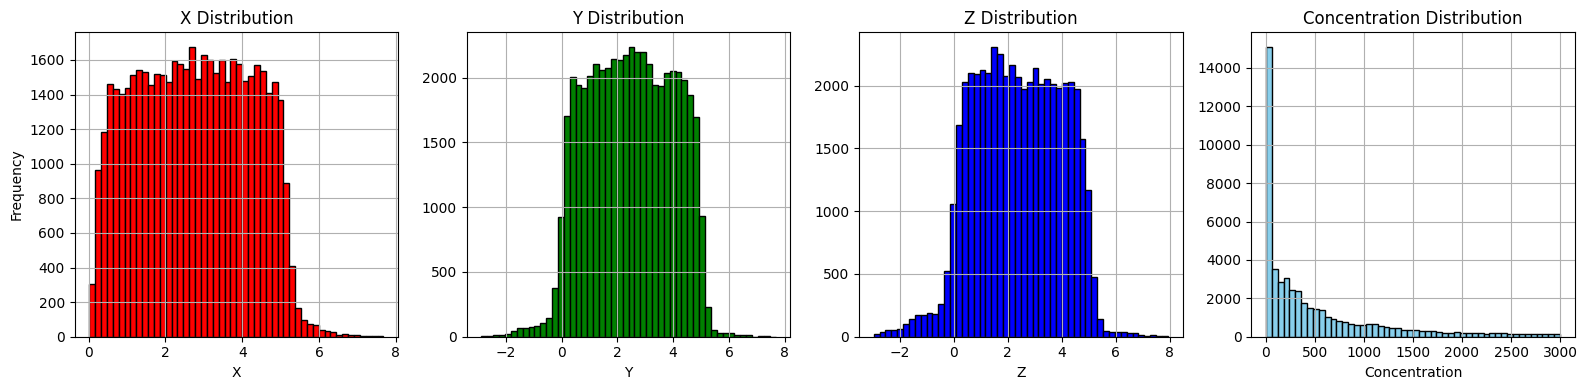

IndexError: invalid index to scalar variable.

In [133]:
# mask = np.any(X_train[:, :, 3] >= 1, axis=1)

# Apply the mask to filter the samples
# X_train_filtered = X_train[mask]
# y_train_filtered = y_train[mask]
point_spread(X_train_filtered)
point_spread(y_train_filtered)

In [129]:
model = build_resnet_source_estimator()
model.compile(optimizer='adam', loss=conc_loss)  # or just 'mse'
model.fit(X_train_filtered, y_train_filtered, validation_data=(X_val, Y_val), epochs=100, batch_size=32)

Epoch 1/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 110.2699 - val_loss: 9182.5166
Epoch 2/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 102.8017 - val_loss: 4372.3403
Epoch 3/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 102.0491 - val_loss: 4617.5659
Epoch 4/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 101.5644 - val_loss: 4161.8779
Epoch 5/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 101.4898 - val_loss: 3015.1370
Epoch 6/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 101.3100 - val_loss: 1880.3394
Epoch 7/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 101.1986 - val_loss: 1775.3666
Epoch 8/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 100.9328 - val_loss: 3631.5215
Epoch 9/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 101.0277 - val_loss: 3158.1709
Epoch 10/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 100.9480 - val_loss: 2309.2444
Epoch 11/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 100.7531 - val_lo

KeyboardInterrupt: 

Attempting MLP

In [134]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(12,)),                     # 3 drones × (x, y, z, c)
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(3, activation='linear')           # Output: (x₀, y₀, z₀)
])

model.compile(optimizer='adam', loss='mse')


In [ ]:
def gaussian_plume_concentration(x0, y0, z0, x, y, z, Q=1.0, u=1.0, sy=1.0, sz=1.0):
    dx = x - x0
    dy = y - y0
    dz = z - z0
    eps = 1e-6  # avoid division by 0
    exponent_y = - (dy ** 2) / (2 * sy ** 2 + eps)
    exponent_z = - (dz ** 2) / (2 * sz ** 2 + eps)
    denom = 2 * np.pi * u * sy * sz + eps
    return Q * np.exp(exponent_y) * np.exp(exponent_z) / denom


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

# --- PHYSICS PLUME FUNCTION ---
def gaussian_plume(x0, y0, z0, x, y, z, Q=1.0, u=1.0, sy=1.0, sz=1.0, eps=1e-6):
    dx = x - x0
    dy = y - y0
    dz = z - z0
    exp_y = tf.exp(- (dy ** 2) / (2 * sy ** 2 + eps))
    exp_z = tf.exp(- (dz ** 2) / (2 * sz ** 2 + eps))
    denom = 2 * np.pi * u * sy * sz + eps
    return Q * exp_y * exp_z / denom

# --- DATA GENERATION ---
def generate_sample():
    # Random source location
    x0, y0, z0 = np.random.uniform(0, 10, size=3)

    # 3 drone locations
    drone_positions = np.random.uniform(0, 10, size=(3, 3))

    # Compute concentrations from plume
    Q, u, sy, sz = 1.0, 1.0, 1.0, 1.0
    concentrations = []
    for x, y, z in drone_positions:
        c = gaussian_plume(x0, y0, z0, x, y, z, Q, u, sy, sz)
        concentrations.append(c)

    # Input: flattened [x1, y1, z1, c1, ..., x3, y3, z3, c3]
    x_input = np.concatenate([np.append(pos, c) for pos, c in zip(drone_positions, concentrations)])
    y_output = np.array([x0, y0, z0])

    return x_input.astype(np.float32), y_output.astype(np.float32)

# --- BUILD DATASET ---
def build_dataset(n_samples):
    X, Y = zip(*[generate_sample() for _ in range(n_samples)])
    return np.stack(X), np.stack(Y)

# --- MODEL DEFINITION ---
def create_model():
    inputs = Input(shape=(12,))
    x = Dense(128, activation='relu')(inputs)
    x = Dense(128, activation='relu')(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(3, activation='linear')(x)
    return Model(inputs, outputs)

# --- PHYSICS-AUGMENTED LOSS ---
def physics_loss(y_true, y_pred, X_input, lambda_source=0.5, lambda_conc=0.5):
    mse_source = tf.reduce_mean(tf.square(y_true - y_pred))

    # Recompute predicted concentrations using predicted source
    # Extract drone positions and measured concentrations from input
    drones = tf.reshape(X_input[:, :9], (-1, 3, 3))  # (batch, 3 drones, (x, y, z))
    true_concs = tf.reshape(X_input[:, 9:], (-1, 3))  # (batch, 3 concs)

    # Repeat predicted source for each drone
    y_pred_exp = tf.expand_dims(y_pred, axis=1)  # (batch, 1, 3)
    src_x, src_y, src_z = tf.unstack(y_pred_exp, axis=-1)
    dr_x, dr_y, dr_z = tf.unstack(drones, axis=-1)

    c_preds = gaussian_plume(src_x, src_y, src_z, dr_x, dr_y, dr_z)
    mse_conc = tf.reduce_mean(tf.square(c_preds - true_concs))

    return lambda_source * mse_source + lambda_conc * mse_conc

# --- CUSTOM TRAINING LOOP ---
def train_model(model, X_train, y_train, epochs=100, batch_size=32):
    optimizer = Adam(1e-3)

    train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).batch(batch_size)

    for epoch in range(epochs):
        total_loss = 0.0
        for X_batch, y_batch in train_dataset:
            with tf.GradientTape() as tape:
                y_pred = model(X_batch, training=True)
                loss = physics_loss(y_batch, y_pred, X_batch)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            total_loss += loss.numpy()

        print(f"Epoch {epoch+1}: Loss = {total_loss / len(train_dataset):.4f}")

        # Evaluate on val set
        y_pred = model.predict(X_val)
        euclidean_error = np.linalg.norm(y_pred - y_val, axis=1)
        conc_error = conc_loss(y_pred, y_val)
        print(f"Mean Euclidean Error (validation): {np.mean(euclidean_error):.3f}")
        print(f"Mean Euclidean Error (validation): {np.mean(conc_error):.3f}")

# --- MAIN EXECUTION ---
if __name__ == "__main__":
            X_train, y_train = build_dataset(5000)
            X_val, y_val = build_dataset(500)

            model = create_model()
            train_model(model, X_train, y_train, epochs=200)


Epoch 1: Loss = 16.1151
Epoch 2: Loss = 15.6430
Epoch 3: Loss = 15.5636
Epoch 4: Loss = 15.5610
Epoch 5: Loss = 15.5143
Epoch 6: Loss = 15.4979
Epoch 7: Loss = 15.4952
Epoch 8: Loss = 15.4592
Epoch 9: Loss = 15.4423
Epoch 10: Loss = 15.4028
Epoch 11: Loss = 15.4202
Epoch 12: Loss = 15.3762
Epoch 13: Loss = 15.3467


2025-07-15 13:30:58.669047: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 14: Loss = 15.3192
Epoch 15: Loss = 15.2935
Epoch 16: Loss = 15.2844
Epoch 17: Loss = 15.2581
Epoch 18: Loss = 15.2197
Epoch 19: Loss = 15.2019
Epoch 20: Loss = 15.1667
Epoch 21: Loss = 15.1696
Epoch 22: Loss = 15.0718
Epoch 23: Loss = 15.0855
Epoch 24: Loss = 15.0629
Epoch 25: Loss = 15.0057
Epoch 26: Loss = 14.9747
Epoch 27: Loss = 14.9194
Epoch 28: Loss = 14.8652
Epoch 29: Loss = 14.8546
Epoch 30: Loss = 14.8022
Epoch 31: Loss = 14.7631
Epoch 32: Loss = 14.7233
Epoch 33: Loss = 14.6991
Epoch 34: Loss = 14.6387
Epoch 35: Loss = 14.6326
Epoch 36: Loss = 14.5487
Epoch 37: Loss = 14.5263
Epoch 38: Loss = 14.4985
Epoch 39: Loss = 14.4234
Epoch 40: Loss = 14.4151
Epoch 41: Loss = 14.3729
Epoch 42: Loss = 14.2972
Epoch 43: Loss = 14.2755
Epoch 44: Loss = 14.2233
Epoch 45: Loss = 14.2048
Epoch 46: Loss = 14.1828
Epoch 47: Loss = 14.1124
Epoch 48: Loss = 14.0812
Epoch 49: Loss = 14.0348
Epoch 50: Loss = 14.0284
Epoch 51: Loss = 13.9939
Epoch 52: Loss = 13.9385
Epoch 53: Loss = 13.9179


2025-07-15 13:33:45.053613: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 78: Loss = 13.2495
Epoch 79: Loss = 13.1623
Epoch 80: Loss = 13.1859
Epoch 81: Loss = 13.1226
Epoch 82: Loss = 13.1232
Epoch 83: Loss = 13.1133
Epoch 84: Loss = 13.1133
Epoch 85: Loss = 13.0746
Epoch 86: Loss = 13.0438
Epoch 87: Loss = 13.0655
Epoch 88: Loss = 13.0206
Epoch 89: Loss = 12.9781
Epoch 90: Loss = 12.9977
Epoch 91: Loss = 12.9841
Epoch 92: Loss = 12.9272
Epoch 93: Loss = 12.9198
Epoch 94: Loss = 12.8804
Epoch 95: Loss = 12.8593
Epoch 96: Loss = 12.8632
Epoch 97: Loss = 12.8233
Epoch 98: Loss = 12.7847
Epoch 99: Loss = 12.8169
Epoch 100: Loss = 12.8014
Epoch 101: Loss = 12.7617
Epoch 102: Loss = 12.7792
Epoch 103: Loss = 12.7313
Epoch 104: Loss = 12.7079
Epoch 105: Loss = 12.7047
Epoch 106: Loss = 12.6971
Epoch 107: Loss = 12.6904
Epoch 108: Loss = 12.7135
Epoch 109: Loss = 12.6391
Epoch 110: Loss = 12.6692
Epoch 111: Loss = 12.6278
Epoch 112: Loss = 12.6081
Epoch 113: Loss = 12.5776
Epoch 114: Loss = 12.5798
Epoch 115: Loss = 12.5905
Epoch 116: Loss = 12.5459
Epoch 11